In [19]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("nij_challenge2021_full_dataset.csv")

# Quick check of key columns we need
required_cols = [
    "ID",
    "Race",
    "Gender",
    "Recidivism_Arrest_Year1",
    "Recidivism_Arrest_Year2",
    "Recidivism_Within_3years"
]

print("Missing required columns:", [c for c in required_cols if c not in df.columns])

# Robust converter: handles Yes/No, Y/N, 1/0, True/False
def to_binary(series):
    mapping = {
        "YES": 1, "NO": 0,
        "Y": 1, "N": 0,
        "TRUE": 1, "FALSE": 0,
        "1": 1, "0": 0
    }

    s = series.astype(str).str.strip().str.upper()
    out = s.map(mapping)

    # if already numeric-like, fill from numeric conversion
    numeric = pd.to_numeric(series, errors="coerce")
    out = out.fillna(numeric)

    return out.astype(int)

# Sensitive attributes
A_race = df["Race"].astype(str).str.strip()
A_gender = df["Gender"].astype(str).str.strip()
A_intersection = A_race + "_" + A_gender

# Correct horizon targets for YOUR proposal
year1 = to_binary(df["Recidivism_Arrest_Year1"])
year2_period = to_binary(df["Recidivism_Arrest_Year2"])
y_1yr = year1
y_2yr = ((year1 == 1) | (year2_period == 1)).astype(int)
y_3yr = to_binary(df["Recidivism_Within_3years"])

print("Dataset shape:", df.shape)
print("\nRace counts:\n", A_race.value_counts(dropna=False))
print("\nGender counts:\n", A_gender.value_counts(dropna=False))

print("\nTarget distributions:")
print("y_1yr:\n", y_1yr.value_counts(dropna=False).sort_index())
print("y_2yr:\n", y_2yr.value_counts(dropna=False).sort_index())
print("y_3yr:\n", y_3yr.value_counts(dropna=False).sort_index())

Missing required columns: []
Dataset shape: (25835, 54)

Race counts:
 Race
BLACK    14847
WHITE    10988
Name: count, dtype: int64

Gender counts:
 Gender
M    22668
F     3167
Name: count, dtype: int64

Target distributions:
y_1yr:
 Recidivism_Arrest_Year1
0    18111
1     7724
Name: count, dtype: int64
y_2yr:
 0    13544
1    12291
Name: count, dtype: int64
y_3yr:
 Recidivism_Within_3years
0    10931
1    14904
Name: count, dtype: int64


In [20]:
# Step 2: Build feature matrix X

# Drop columns that should NEVER be used
drop_cols = [
    "ID",
    "Training_Sample",

    # Targets
    "Recidivism_Within_3years",
    "Recidivism_Arrest_Year1",
    "Recidivism_Arrest_Year2",
    "Recidivism_Arrest_Year3",
]

# Drop post-release leakage features
leakage_cols = [col for col in df.columns if (
    col.startswith("Violations_") or
    col.startswith("DrugTests_") or
    col.startswith("Program_") or
    col in [
        "Residence_Changes",
        "Avg_Days_per_DrugTest",
        "Percent_Days_Employed",
        "Jobs_Per_Year",
        "Employment_Exempt"
    ]
)]

# Final columns to drop
all_drop = drop_cols + leakage_cols

# Create feature dataframe
X_raw = df.drop(columns=all_drop, errors="ignore")

# One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Sample columns:", X.columns[:20])

Feature matrix shape: (25835, 86)
Sample columns: Index(['Residence_PUMA', 'Supervision_Risk_Score_First', 'Gender_M',
       'Race_WHITE', 'Age_at_Release_23-27', 'Age_at_Release_28-32',
       'Age_at_Release_33-37', 'Age_at_Release_38-42', 'Age_at_Release_43-47',
       'Age_at_Release_48 or older', 'Gang_Affiliated_Yes',
       'Supervision_Level_First_Specialized',
       'Supervision_Level_First_Standard',
       'Education_Level_High School Diploma',
       'Education_Level_Less than HS diploma', 'Dependents_1', 'Dependents_2',
       'Dependents_3 or more', 'Prison_Offense_Other',
       'Prison_Offense_Property'],
      dtype='object')


In [21]:
from sklearn.model_selection import train_test_split

# Step 3: ONE consistent split

X_train, X_test, y1_train, y1_test, y2_train, y2_test, y3_train, y3_test, race_train, race_test, gender_train, gender_test, inter_train, inter_test = train_test_split(
    X,
    y_1yr,
    y_2yr,
    y_3yr,
    A_race,
    A_gender,
    A_intersection,
    test_size=0.2,
    random_state=42,
    stratify=y_1yr   # stratify on Year1 (most stable)
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTarget distributions (test):")
print("Year1:\n", y1_test.value_counts(normalize=True))
print("Year2:\n", y2_test.value_counts(normalize=True))
print("Year3:\n", y3_test.value_counts(normalize=True))

Train size: (20668, 86)
Test size: (5167, 86)

Target distributions (test):
Year1:
 Recidivism_Arrest_Year1
0    0.700987
1    0.299013
Name: proportion, dtype: float64
Year2:
 0    0.520225
1    0.479775
Name: proportion, dtype: float64
Year3:
 Recidivism_Within_3years
1    0.583704
0    0.416296
Name: proportion, dtype: float64


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n===== {label} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1       :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return y_pred, y_prob

# Train models for all 3 horizons

y1_pred, y1_prob = train_and_evaluate(X_train, X_test, y1_train, y1_test, "YEAR 1")
y2_pred, y2_prob = train_and_evaluate(X_train, X_test, y2_train, y2_test, "YEAR 2")
y3_pred, y3_prob = train_and_evaluate(X_train, X_test, y3_train, y3_test, "YEAR 3")


===== YEAR 1 =====
Accuracy : 0.6626669247145346
Precision: 0.45691906005221933
Recall   : 0.6796116504854369
F1       : 0.546448087431694
ROC-AUC  : 0.7352575683659192
Confusion Matrix:
 [[2374 1248]
 [ 495 1050]]

===== YEAR 2 =====
Accuracy : 0.6667311786336365
Precision: 0.64642166344294
Recall   : 0.6740621218233158
F1       : 0.659952606635071
ROC-AUC  : 0.7328216242628556
Confusion Matrix:
 [[1774  914]
 [ 808 1671]]

===== YEAR 3 =====
Accuracy : 0.6791174762918522
Precision: 0.7460144927536232
Recall   : 0.6826923076923077
F1       : 0.7129501385041551
ROC-AUC  : 0.7470424279867361
Confusion Matrix:
 [[1450  701]
 [ 957 2059]]


In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score
import pandas as pd
import numpy as np

def compute_group_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    return {
        "TPR": tp / (tp + fn) if (tp + fn) else 0,
        "FPR": fp / (fp + tn) if (fp + tn) else 0,
        "FNR": fn / (fn + tp) if (fn + tp) else 0,
        "Selection_Rate": np.mean(y_pred),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0)
    }

def fairness_by_group(y_true, y_pred, group_series, group_name):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    group_series = pd.Series(group_series).reset_index(drop=True)

    results = []

    for g in group_series.unique():
        mask = (group_series == g)
        metrics = compute_group_metrics(y_true[mask], y_pred[mask])
        metrics[group_name] = g
        metrics["Count"] = int(mask.sum())
        results.append(metrics)

    df = pd.DataFrame(results)
    return df[[group_name, "Count", "TPR", "FPR", "FNR", "Selection_Rate", "Accuracy", "Precision"]]

def compute_gaps(df):
    return pd.Series({
        col + "_Diff": df[col].max() - df[col].min()
        for col in ["TPR", "FPR", "FNR", "Selection_Rate", "Accuracy", "Precision"]
    })

In [24]:
# YEAR 1 FAIRNESS

race_fairness_y1 = fairness_by_group(y1_test, y1_pred, race_test, "Race")
gender_fairness_y1 = fairness_by_group(y1_test, y1_pred, gender_test, "Gender")
inter_fairness_y1 = fairness_by_group(y1_test, y1_pred, inter_test, "Group")

print("\n=== YEAR 1 RACE ===")
print(race_fairness_y1)

print("\n=== YEAR 1 GENDER ===")
print(gender_fairness_y1)

print("\n=== YEAR 1 INTERSECTION ===")
print(inter_fairness_y1)

print("\n=== YEAR 1 GAPS (RACE) ===")
print(compute_gaps(race_fairness_y1))

print("\n=== YEAR 1 GAPS (GENDER) ===")
print(compute_gaps(gender_fairness_y1))

print("\n=== YEAR 1 GAPS (INTERSECTION) ===")
print(compute_gaps(inter_fairness_y1))


=== YEAR 1 RACE ===
    Race  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0  BLACK   3006  0.696872  0.381914  0.303128        0.479042  0.642382   
1  WHITE   2161  0.653722  0.294232  0.346278        0.397038  0.690884   

   Precision  
0   0.448611  
1   0.470862  

=== YEAR 1 GENDER ===
  Gender  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0      M   4509  0.696229  0.375366  0.303771        0.477268  0.647372   
1      F    658  0.469027  0.170642  0.530973        0.221884  0.767477   

   Precision  
0   0.463290  
1   0.363014  

=== YEAR 1 INTERSECTION ===
     Group  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0  BLACK_M   2766  0.711845  0.403072  0.288155        0.501085  0.633406   
1  WHITE_M   1743  0.671480  0.331371  0.328520        0.439472  0.669535   
2  WHITE_F    418  0.500000  0.169492  0.500000        0.220096  0.779904   
3  BLACK_F    240  0.428571  0.172775  0.571429        0.225000  0.745833   


In [25]:
# YEAR 2 FAIRNESS

race_fairness_y2 = fairness_by_group(y2_test, y2_pred, race_test, "Race")
gender_fairness_y2 = fairness_by_group(y2_test, y2_pred, gender_test, "Gender")
inter_fairness_y2 = fairness_by_group(y2_test, y2_pred, inter_test, "Group")

print("\n=== YEAR 2 RACE ===")
print(race_fairness_y2)

print("\n=== YEAR 2 GENDER ===")
print(gender_fairness_y2)

print("\n=== YEAR 2 INTERSECTION ===")
print(inter_fairness_y2)

race_gap_y2 = compute_gaps(race_fairness_y2)
gender_gap_y2 = compute_gaps(gender_fairness_y2)
inter_gap_y2 = compute_gaps(inter_fairness_y2)


# YEAR 3 FAIRNESS

race_fairness_y3 = fairness_by_group(y3_test, y3_pred, race_test, "Race")
gender_fairness_y3 = fairness_by_group(y3_test, y3_pred, gender_test, "Gender")
inter_fairness_y3 = fairness_by_group(y3_test, y3_pred, inter_test, "Group")

print("\n=== YEAR 3 RACE ===")
print(race_fairness_y3)

print("\n=== YEAR 3 GENDER ===")
print(gender_fairness_y3)

print("\n=== YEAR 3 INTERSECTION ===")
print(inter_fairness_y3)

race_gap_y3 = compute_gaps(race_fairness_y3)
gender_gap_y3 = compute_gaps(gender_fairness_y3)
inter_gap_y3 = compute_gaps(inter_fairness_y3)


=== YEAR 2 RACE ===
    Race  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0  BLACK   3006  0.686813  0.369677  0.313187        0.523287  0.657685   
1  WHITE   2161  0.655914  0.299649  0.344086        0.468302  0.679315   

   Precision  
0   0.635728  
1   0.663043  

=== YEAR 2 GENDER ===
  Gender  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0      M   4509  0.701466  0.374668  0.298534        0.537813   0.66334   
1      F    658  0.403509  0.158140  0.596491        0.243161   0.68997   

   Precision  
0   0.651134  
1   0.575000  

=== YEAR 2 INTERSECTION ===
     Group  Count       TPR       FPR       FNR  Selection_Rate  Accuracy  \
0  BLACK_M   2766  0.703114  0.393502  0.296886        0.548084  0.654736   
1  WHITE_M   1743  0.698851  0.344788  0.301149        0.521515  0.676994   
2  WHITE_F    418  0.411765  0.150943  0.588235        0.246411  0.688995   
3  BLACK_F    240  0.386667  0.169697  0.613333        0.237500  0.691667   


In [26]:
final_table = pd.DataFrame({
    "Year": ["Year1", "Year2", "Year3"],

    # Race gaps
    "Race_TPR_Diff": [
        compute_gaps(race_fairness_y1)["TPR_Diff"],
        compute_gaps(race_fairness_y2)["TPR_Diff"],
        compute_gaps(race_fairness_y3)["TPR_Diff"]
    ],
    "Race_FPR_Diff": [
        compute_gaps(race_fairness_y1)["FPR_Diff"],
        compute_gaps(race_fairness_y2)["FPR_Diff"],
        compute_gaps(race_fairness_y3)["FPR_Diff"]
    ],

    # Gender gaps
    "Gender_TPR_Diff": [
        compute_gaps(gender_fairness_y1)["TPR_Diff"],
        compute_gaps(gender_fairness_y2)["TPR_Diff"],
        compute_gaps(gender_fairness_y3)["TPR_Diff"]
    ],
    "Gender_FPR_Diff": [
        compute_gaps(gender_fairness_y1)["FPR_Diff"],
        compute_gaps(gender_fairness_y2)["FPR_Diff"],
        compute_gaps(gender_fairness_y3)["FPR_Diff"]
    ],

    # Intersection gaps
    "Inter_TPR_Diff": [
        compute_gaps(inter_fairness_y1)["TPR_Diff"],
        compute_gaps(inter_fairness_y2)["TPR_Diff"],
        compute_gaps(inter_fairness_y3)["TPR_Diff"]
    ],
    "Inter_FPR_Diff": [
        compute_gaps(inter_fairness_y1)["FPR_Diff"],
        compute_gaps(inter_fairness_y2)["FPR_Diff"],
        compute_gaps(inter_fairness_y3)["FPR_Diff"]
    ]
})

print(final_table)

    Year  Race_TPR_Diff  Race_FPR_Diff  Gender_TPR_Diff  Gender_FPR_Diff  \
0  Year1       0.043150       0.087682         0.227203         0.204723   
1  Year2       0.030899       0.070029         0.297957         0.216528   
2  Year3       0.011026       0.048722         0.275767         0.239609   

   Inter_TPR_Diff  Inter_FPR_Diff  
0        0.283274        0.233581  
1        0.316447        0.242558  
2        0.295030        0.261744  


In [27]:
temporal_summary = pd.DataFrame({
    "Year": ["Year1", "Year2", "Year3"],

    "Race_FPR_Gap": [
        compute_gaps(race_fairness_y1)["FPR_Diff"],
        compute_gaps(race_fairness_y2)["FPR_Diff"],
        compute_gaps(race_fairness_y3)["FPR_Diff"]
    ],

    "Gender_TPR_Gap": [
        compute_gaps(gender_fairness_y1)["TPR_Diff"],
        compute_gaps(gender_fairness_y2)["TPR_Diff"],
        compute_gaps(gender_fairness_y3)["TPR_Diff"]
    ],

    "Intersection_TPR_Gap": [
        compute_gaps(inter_fairness_y1)["TPR_Diff"],
        compute_gaps(inter_fairness_y2)["TPR_Diff"],
        compute_gaps(inter_fairness_y3)["TPR_Diff"]
    ]
})

print(temporal_summary)

    Year  Race_FPR_Gap  Gender_TPR_Gap  Intersection_TPR_Gap
0  Year1      0.087682        0.227203              0.283274
1  Year2      0.070029        0.297957              0.316447
2  Year3      0.048722        0.275767              0.295030


In [28]:
from sklearn.calibration import calibration_curve

def calibration_by_group(y_true, y_prob, group):
    df = pd.DataFrame({
        "y": y_true,
        "prob": y_prob,
        "group": group
    })

    results = {}

    for g in df["group"].unique():
        frac_pos, mean_pred = calibration_curve(
            df[df["group"] == g]["y"],
            df[df["group"] == g]["prob"],
            n_bins=5
        )
        results[g] = (mean_pred, frac_pos)

    return results

In [29]:
multi_metric_table = pd.DataFrame({
    "Metric": [
        "Demographic Parity",
        "Equal Opportunity",
        "FPR Parity",
        "Predictive Parity",
        "Accuracy Parity"
    ],

    "Year1 Gap": [
        compute_gaps(race_fairness_y1)["Selection_Rate_Diff"],
        compute_gaps(race_fairness_y1)["TPR_Diff"],
        compute_gaps(race_fairness_y1)["FPR_Diff"],
        compute_gaps(race_fairness_y1)["Precision_Diff"],
        compute_gaps(race_fairness_y1)["Accuracy_Diff"]
    ],

    "Year2 Gap": [
        compute_gaps(race_fairness_y2)["Selection_Rate_Diff"],
        compute_gaps(race_fairness_y2)["TPR_Diff"],
        compute_gaps(race_fairness_y2)["FPR_Diff"],
        compute_gaps(race_fairness_y2)["Precision_Diff"],
        compute_gaps(race_fairness_y2)["Accuracy_Diff"]
    ],

    "Year3 Gap": [
        compute_gaps(race_fairness_y3)["Selection_Rate_Diff"],
        compute_gaps(race_fairness_y3)["TPR_Diff"],
        compute_gaps(race_fairness_y3)["FPR_Diff"],
        compute_gaps(race_fairness_y3)["Precision_Diff"],
        compute_gaps(race_fairness_y3)["Accuracy_Diff"]
    ]
})

print(multi_metric_table)

               Metric  Year1 Gap  Year2 Gap  Year3 Gap
0  Demographic Parity   0.082004   0.054985   0.036047
1   Equal Opportunity   0.043150   0.030899   0.011026
2          FPR Parity   0.087682   0.070029   0.048722
3   Predictive Parity   0.022251   0.027316   0.005532
4     Accuracy Parity   0.048502   0.021631   0.013862


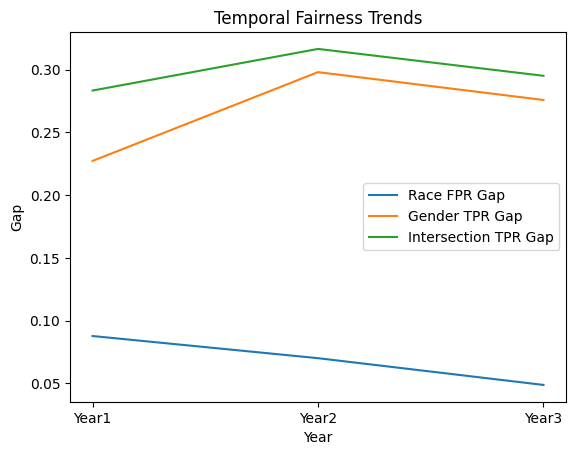

In [30]:
import matplotlib.pyplot as plt

plt.plot(temporal_summary["Year"], temporal_summary["Race_FPR_Gap"], label="Race FPR Gap")
plt.plot(temporal_summary["Year"], temporal_summary["Gender_TPR_Gap"], label="Gender TPR Gap")
plt.plot(temporal_summary["Year"], temporal_summary["Intersection_TPR_Gap"], label="Intersection TPR Gap")

plt.xlabel("Year")
plt.ylabel("Gap")
plt.title("Temporal Fairness Trends")
plt.legend()
plt.show()